<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

from src.algorithms.algorithm import Algorithm
from src.algorithms.epsilon_greedy import EpsilonGreedy, DecayingEpsilonGreedy
from src.algorithms.ucb1 import UCB1
from src.algorithms.softmax import Softmax
from src.arms.arm import Arm
from src.arms.armnormal import ArmNormal
from src.arms.bandit import Bandit
from src.arms.armbinomial import ArmBinomial
from src.plotting.plotting import plot_average_rewards, plot_optimal_selections, plot_regret

seed = 2024
np.random.seed(seed)
random.seed(seed)

In [2]:
def run_experiment(algorithms, n_arms, n_steps, n_runs, n_trials=10):
    """
    Ejecuta el experimento para brazos con Distribución Binomial B(n, p).
    """
    # Matrices para almacenar resultados [cite: 314-315]
    all_rewards = np.zeros((len(algorithms), n_steps))
    optimal_counts = np.zeros((len(algorithms), n_steps))
    regret_accumulated = np.zeros((len(algorithms), n_steps))

    # Definimos las probabilidades p de éxito para cada brazo
    probs = np.linspace(0.1, 0.9, n_arms) 
    
    # IMPORTANTE: En la binomial, la media de cada brazo es n * p 
    means = n_trials * probs
    optimal_arm_idx = np.argmax(means)
    max_mu = means[optimal_arm_idx]

    for run in range(n_runs):
        # Instanciamos los brazos con n > 1 para el estudio binomial [cite: 402, 464]
        arms = [ArmBinomial(n=n_trials, p=p) for p in probs]
        bandit = Bandit(arms)
        
        # Reiniciamos algoritmos para cada ejecución independiente [cite: 469]
        for alg in algorithms:
            alg.reset() 

        for step in range(n_steps):
            for i, alg in enumerate(algorithms):
                # 1. Selección de acción según la política [cite: 372-373]
                arm_idx = alg.select_arm()
                
                # 2. Obtención de recompensa (número de éxitos en n ensayos) [cite: 374, 579]
                reward = bandit.pull_arm(arm_idx)
                
                # 3. Actualización del conocimiento del agente [cite: 332, 491]
                alg.update(arm_idx, reward)
                
                # Registro de métricas
                all_rewards[i, step] += reward
                if arm_idx == optimal_arm_idx:
                    optimal_counts[i, step] += 1
                
                # El regret se basa en la diferencia de medias reales (n*p* - n*p_elegido) [cite: 379-381]
                current_regret = max_mu - means[arm_idx]
                regret_accumulated[i, step] += current_regret

    # Promediamos resultados para obtener curvas suaves [cite: 315]
    avg_rewards = all_rewards / n_runs
    avg_optimal = (optimal_counts / n_runs) * 100 
    avg_regret = np.cumsum(regret_accumulated / n_runs, axis=1) 

    return avg_rewards, avg_optimal, avg_regret

In [3]:
# 1. Parámetros del experimento
n_arms = 10
n_steps = 1000
n_runs = 2000 
n_trials = 10  # Cada brazo es una Binomial B(n=10, p)

# 2. Lista de algoritmos a comparar
# Ajustamos la temperatura de Softmax proporcionalmente al valor de n_trials
all_algorithms = [
    EpsilonGreedy(k=n_arms, epsilon=0.1),
    DecayingEpsilonGreedy(k=n_arms),
    UCB1(k=n_arms),
    Softmax(k=n_arms, temperature=1.0) # Subimos a 1.0 porque las recompensas son x10
]

# 3. Ejecución (llamando a la función que configuramos con n_trials)
avg_rewards, opt_selections, regret_data = run_experiment(
    all_algorithms, 
    n_arms, 
    n_steps, 
    n_runs, 
    n_trials=n_trials
)

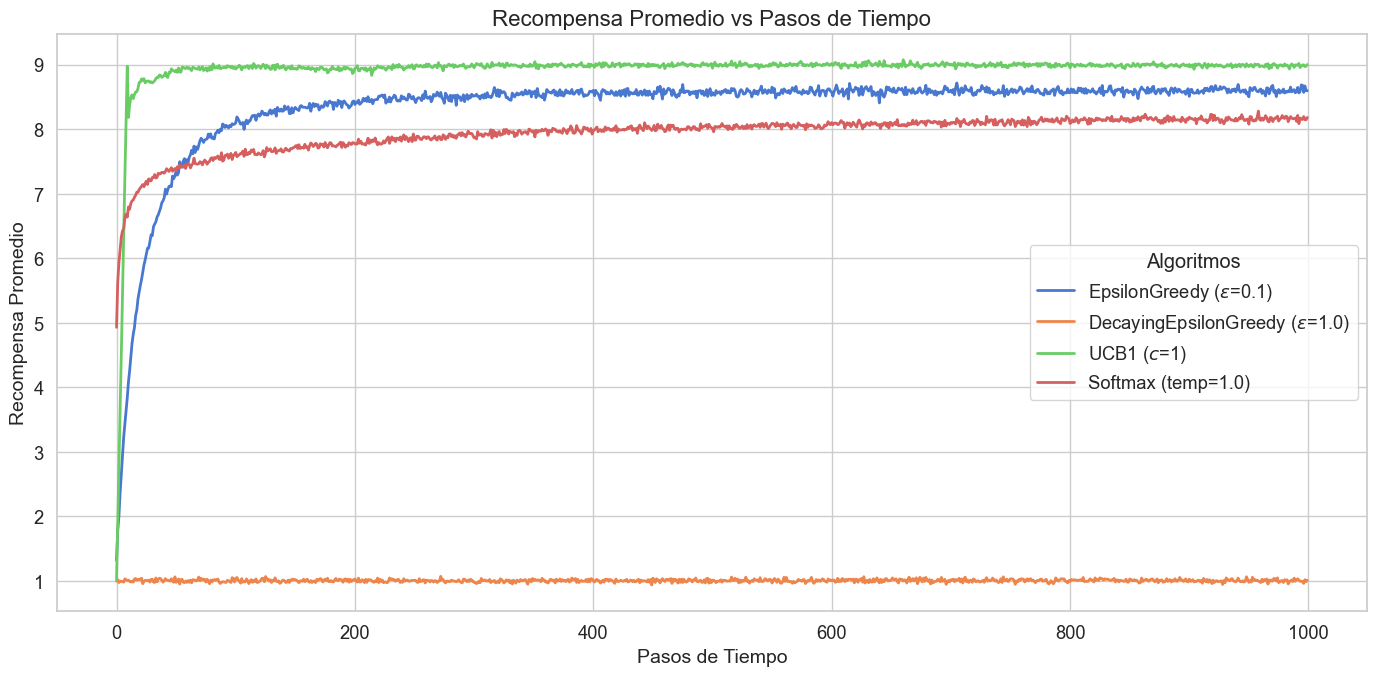

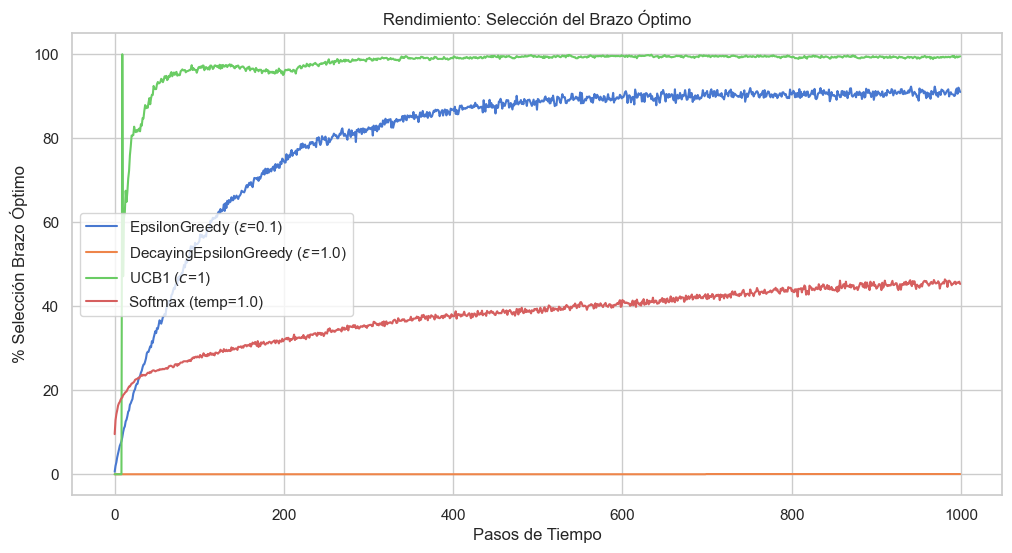

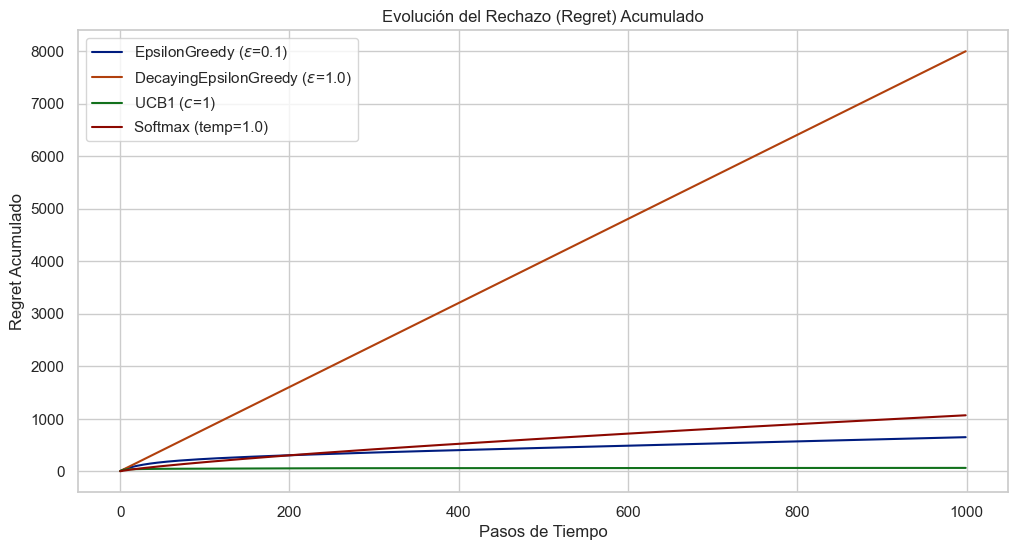

In [4]:
# Gráfica 1: Recompensa Promedio (Verás que el máximo ronda los 9.0, que es n * p_max)
plot_average_rewards(n_steps, avg_rewards, all_algorithms)

# Gráfica 2: % de Selección del Brazo Óptimo
plot_optimal_selections(n_steps, opt_selections, all_algorithms)

# Gráfica 3: Regret Acumulado
plot_regret(n_steps, regret_data, all_algorithms)